## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 15.09it/s]


Numba compilation complete!
0.23.7


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025meandiffcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [36]:
def twolightdabest(di, names, parameter, light):
    
    if light == 'Half' or light == 'Full':
        dfi = di[(di['light_intensity']==light)].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['status'] == 'Offspring')].reset_index(drop=True)
        filter2 = dfi[(dfi['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names + " " + light] = filter1[parameter]
       
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
        
    if light == 'Both':
        
        df_half = di[(di['light_intensity']=="Half")].reset_index(drop=True)
        dfrr = pd.DataFrame()
        filter1_half = df_half[(df_half['status'] == 'Offspring')].reset_index(drop=True)
        filter2_half = df_half[(df_half['status'] == 'Sibling')].reset_index(drop=True)
        
        df_full = di[(di['light_intensity']=="Full")].reset_index(drop=True)
        filter1_full = df_full[(df_full['status'] == 'Offspring')].reset_index(drop=True)
        filter2_full = df_full[(df_full['status'] == 'Sibling')].reset_index(drop=True)
                
        dfrr["Cntrl_Half"] = filter2_half[parameter]
        dfrr[ "Half"] = filter1_half[parameter]
        dfrr["Cntrl_Full" ] = filter2_full[parameter]
        dfrr["Full"] = filter1_full[parameter]
        l = dfrr.columns.tolist()
        titlelst = list(zip(l,l[1:]))[::2]  
        test = dabest.load(dfrr, idx=titlelst)    
    
    return test

def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
        
def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]

    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 

    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    tabletotallst = [pitable, sptable, pctable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

        
def reading_OSAR_compiled_files(df, responder):
    df['genotypeandresponder'] = df['MBON'] + "_" + responder
    
    return df


## Formulas to run


In [8]:
newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025fallingtoosarcomp\\"
files2 = os.listdir(newfile2)


#mbon locations
MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## To regenerate excel file for OSAR and Falling data combination specifically

In [56]:
#pre processed fallin
root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\"
filefalling = root + "Falling.xlsx"
df_falling = pd.read_excel(filefalling)

cols = df_falling.columns.tolist()
cols[1:-2] = [col + '_Falling' for col in cols[1:-2]]
df_falling.columns = cols

df_falling = df_falling.drop(columns= ["MBON"])

In [65]:
#pre run osar stuff
root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\"
filepathACR = root + "OSAR_ACR.xlsx"
filepathCR2 = root + "OSAR_Chrimson2.xlsx"
filepathlogratio = root + "OSAR and Falling_delta Log2SR and delta Log2BSR comparison.xlsx"  #File generated from 2025fallingtoosarcomp

dffileACR= reading_OSAR_compiled_files(pd.read_excel(filepathACR), "ACR")
dffileCR2= reading_OSAR_compiled_files(pd.read_excel(filepathCR2),'Chrimson2')
dffilelogratio = pd.read_excel(filepathlogratio)

dfosartotal= pd.concat([dffileACR, dffileCR2], axis = 0).reset_index(drop=True)
dfosartotal = dfosartotal.rename(columns={'Δ PI': 'PI_Δg_OSAR', "Δ Log2_Speed_ratio": "Log2 Speed ratio_Δg_OSAR",
                                          "Δ Log2_Bout Speed_ratio": "Log2 Bout Speed ratio_Δg_OSAR", "Δ Light Attraction Index": "Light Attraction Index_Δg_OSAR"
                                          })

dflogratiofalling = dffilelogratio.iloc[:,-3:].rename(columns={"Δ Log2 Speed Ratio_Falling": "Log2 Speed ratio_Δg_Falling",
                                          "Δ Log2 Bout Speed Ratio_Falling": "Log2 Bout Speed ratio_Δg_Falling"
                                          })

In [66]:
dfmix = df_falling.merge(dfosartotal, on="genotypeandresponder", how="inner") \
                  .merge(dflogratiofalling, on="genotypeandresponder", how="inner")
dfmix = dfmix.sort_values(by = ["genotypeandresponder"])

totalmetriccomparison = dfmix[~dfmix['MBON'].isin(['R58', 'Th-Gal4'])]

totalmetriccomparison.to_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics.xlsx", index = False)
print("File made")

File made


## for rerunning of total excel files should there be changes

In [ ]:
# # To run if need new files to generate for compiled work

# #pre
# newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025fallingtoosarcomp\\"
# files2 = os.listdir(newfile2)

# # falling stuff
# from collections import Counter
# counts = Counter([item.split(' ')[0] for item in files2])
# matchingsets = [value for value, count in counts.items() if count > 1]  #only if you have both ACR and Chrimson data
# matchinglst = [v for v in files2 if any(short_name in v for short_name in matchingsets)]
# dfreg_ACR = pd.DataFrame()
# dfreg_Chrimson2 = pd.DataFrame()

# for f in matchinglst:
#     if "Chrimson2" in f:
#         temp = pd.read_csv(newfile2 + f, index_col=0)
#         temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
#         dfreg_Chrimson2 = pd.concat([dfreg_Chrimson2, temp], axis = 0)
#     if "ACR" in f:
#         temp = pd.read_csv(newfile2 + f, index_col=0)
#         temp = temp.loc[:, ~temp.columns.str.endswith('_bootstrap')].drop_duplicates()
#         dfreg_ACR = pd.concat([dfreg_ACR, temp], axis = 0)
        

# dfreg_Chrimson2 = dfreg_Chrimson2.reset_index(drop=False)
# dfreg_Chrimson2['genotypeandresponder'] = dfreg_Chrimson2['MBON'] + '_Chrimson2'

# dfreg_ACR = dfreg_ACR.reset_index(drop=False)
# dfreg_ACR['genotypeandresponder'] = dfreg_ACR['MBON'] + '_ACR'


# #osar stuff
# root = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
# filepathACR = root + "20250311_ACR_totalcompilation.csv"   #run from multi and single dabest OSAR plots ig
# filepathCR2 = root + "20250311_ACR_totalcompilation.csv"

# dffileACR= pd.read_csv(filepathACR, index_col=0)
# dffileCR2= pd.read_csv(filepathCR2, index_col=0)

# dffACR = multiresponder_osar(dffileACR, "ACR")
# dffCR2 = multiresponder_osar(dffileCR2, "Chrimson2")

# dfmultiresponderosar = pd.concat([dffACR, dffCR2]).reset_index(drop=True)
# dfmultiresponderosar['genotypeandresponder'] = dfmultiresponderosar['MBON'] + "_" + dfmultiresponderosar['responder']


# #together

# dfregtotal= pd.concat([dfreg_ACR, dfreg_Chrimson2], axis = 0).reset_index(drop=True)
# dfosartotal = dfregtotal.loc[:,['genotypeandresponder', 'bspeed_hedgesg', 'speed_hedgesg']]

# dfmix = dfmultiresponderosar.merge(dfosartotal, on="genotypeandresponder", how= "inner")
# #dfmix = dfmix.drop(['responder'], axis = 1)
# dfmix = dfmix.sort_values(by = ["genotypeandresponder"])

# osarmatchdf = dfmix[~dfmix['MBON'].isin(['R58', 'Th-Gal4'])]

# to generate excel file only
# osarexcel = osarmatchdf.copy()
# osarexcel = osarexcel.rename(columns={'Δ PI': 'Δ PI_OSAR', 'Δ Log2 Speed Ratio': 'Δ Log2 Speed Ratio_OSAR', 'Δ Log2 Pace Ratio': 'Δ Log2 Bout Speed Ratio_OSAR'
#                              , 'bspeed_hedgesg': 'Δ Log2 Bout Speed Ratio_Falling', 'speed_hedgesg': 'Δ Log2 Speed Ratio_Falling'}).reset_index(drop=True)
# osarexcel.to_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR and Falling_delta Log2SR and delta Log2BSR comparison.xlsx", index = False)

## Heatmap

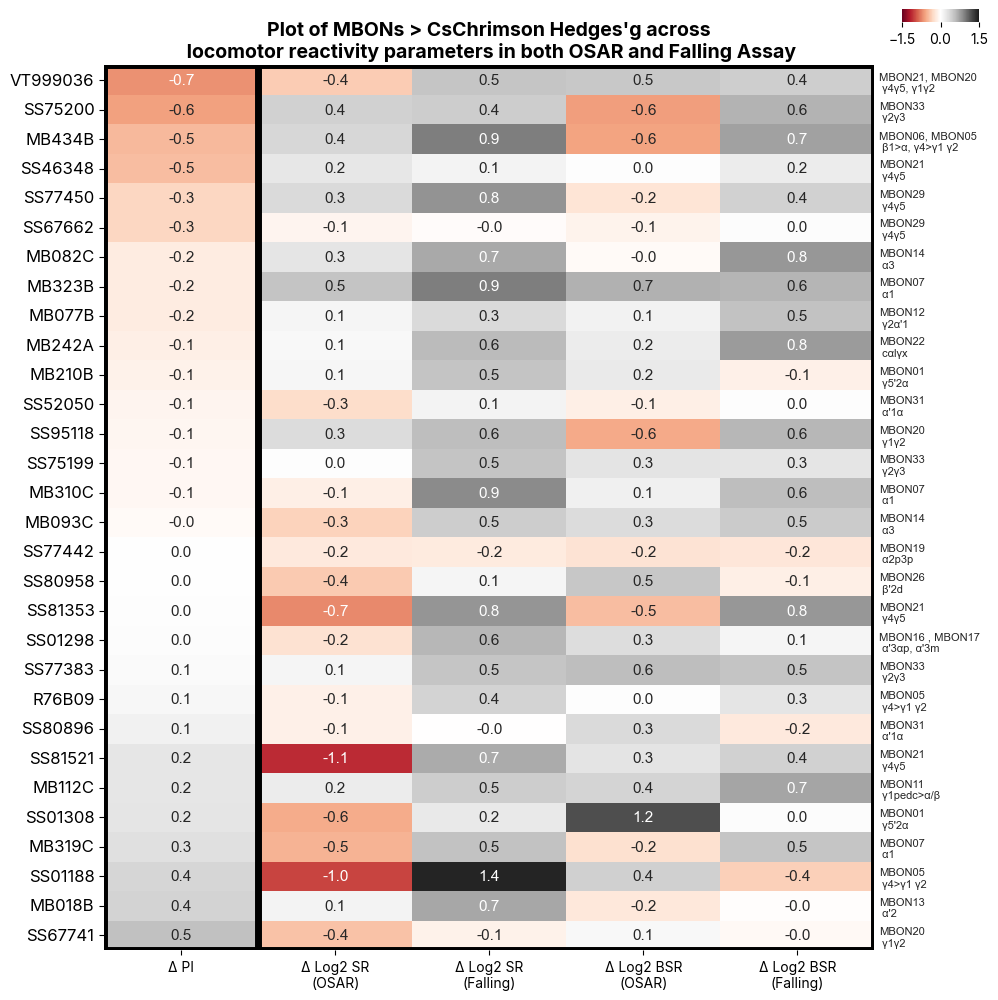

In [11]:
#total mbon list including ACR and chrimson2
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'RdGy'

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by = "Δ PI", ascending=True).reset_index(drop=True)
    colormap = 'BrBG'

df00 = df_specificmbon.set_index(['genotypeandresponder'])
df00.columns = df00.columns.str.replace('_deltag', '')    

fig1, ax3 = plt.subplots(figsize=(10,10))     
#adding extra axes label
lobloclst = []
mbonloclst = []
df500 = df00.copy()
for n in df00['MBON']:    
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df500['Lobe'] = lobloclst
df500['Name'] = mbonloclst

df00 = df00.drop(['MBON', 'responder'], axis =1)
#labelling of MBON number and location but ONLY ifc comparing ACR and CHRIMSON2

# newdf500 = pd.DataFrame()
# naming = df500['Name'].iloc[::2].to_frame().rename(columns = {"Name": ""})
# lobing = df500['Lobe'].iloc[1::2].to_frame().rename(columns = {"Lobe": ""})
# newlabel =(naming.values + "\n " + lobing.values).tolist()
# newdf500['Merge'] = newlabel

#single responder
newdf500 = pd.DataFrame()
naming = df500['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df500['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf500['Merge'] = newlabel

#new labels for heatmap

df00 = df00[['Δ PI', 'Δ Log2 Speed Ratio', 'speed_hedgesg', 'Δ Log2 Pace Ratio', 'bspeed_hedgesg']]
xticklabeldf = df00.rename(columns={'Δ Log2 Speed Ratio': "Δ Log2 SR (OSAR)" , 'Δ Log2 Pace Ratio': "Δ Log2 BSR (OSAR)" ,'bspeed_hedgesg': 'Δ Log2 BSR (Falling)', 'speed_hedgesg': 'Δ Log2 SR (Falling)'})
xticklabellist = xticklabeldf.columns.tolist()
yticklabels = [label.split("_")[0] for label in df00.index]

#colorbar
cax = inset_axes(ax3,
                 width="10%",  # width: 40% of parent_bbox width
                 height="1.5%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.1, 1.08, 1, 1),
                 bbox_transform=ax3.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})           
j7 = sns.heatmap(df00, ax = ax3, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap=colormap, linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=yticklabels
                 , clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5, 0 ,1.5]), annot_kws={"size": 11}) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 12)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 0, fontsize = 10)
wrap_labels(j7, 10)

# Drawing the frame for subplot 1
j7.axhline(y = 0, color = 'k', linewidth = 5) 
j7.axhline(y = len(df00), color = 'k', linewidth = 5) 
j7.axvline(x = 0, color = 'k', linewidth = 5) 
j7.axvline(x = 1, color = 'k', linewidth = 5) 
j7.axvline(x = len(df00.columns), color = 'k', linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())
j8.tick_params(length=0)

#y labels for mbon lobes and naming
labellinglist = newdf500['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    #labelledlist.extend(("", n[0]))  #inserts blank space after every list name
    labelledlist.extend(n)     #either or
    
#j8.set_yticklabels(newdf500['Merge'].iloc[::-1], fontsize=10)
j8.set_yticklabels(labelledlist, fontsize=8)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)


j7.set_title("Plot of MBONs > " + responderrename + " Hedges'g across\n locomotor reactivity parameters in both OSAR and Falling Assay", x=0.5, weight='bold', fontsize =14)

fig1.tight_layout()

plt.savefig(filesavedir + date + "_"+ responder+"_hedgesgheatmap.png", dpi = 1200)
plt.savefig(filesavedir + date + "_"+ responder +"_hedgesgheatmap.svg")

## Valence signs reversal

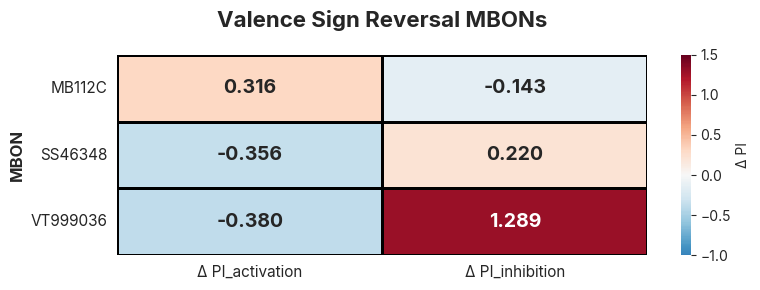

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Read the Excel files
osar_chrimson = pd.read_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_Chrimson2.xlsx")
osar_acr = pd.read_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_ACR.xlsx")

# Extract PI values from both files
activation_pi = osar_chrimson[['MBON', 'Δ PI']].copy()
activation_pi['MBON'] = activation_pi['MBON'].astype(str)
activation_pi = activation_pi.rename(columns={'Δ PI': 'Δ PI_activation'})

inhibition_pi = osar_acr[['MBON', 'Δ PI']].copy()
inhibition_pi['MBON'] = inhibition_pi['MBON'].astype(str)
inhibition_pi = inhibition_pi.rename(columns={'Δ PI': 'Δ PI_inhibition'})

# Create DataFrame for heatmap
heatmap_data = activation_pi.merge(inhibition_pi, how="inner", on= "MBON").set_index("MBON")
mbons_of_interest = ['MB112C', 'SS46348', 'VT999036']
heatmap_data = heatmap_data.loc[mbons_of_interest]

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 3))

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Δ PI'}, 
            linewidths=2, linecolor='black',
            vmin=-1, vmax=1.5,
            annot_kws={'size': 14, 'weight': 'bold'})

# Customize plot
plt.title('Valence Sign Reversal MBONs', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('MBON', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(filesavedir + date + "_valencesigreveralmbons.png", dpi = 1200, bbox_inches='tight')

# Show plot
plt.show()




## Lin reg

In [72]:
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

In [68]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics.xlsx")

responder = "Chrimson2"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
    colorline = "#ff0000"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
    colorline = "#14962c"

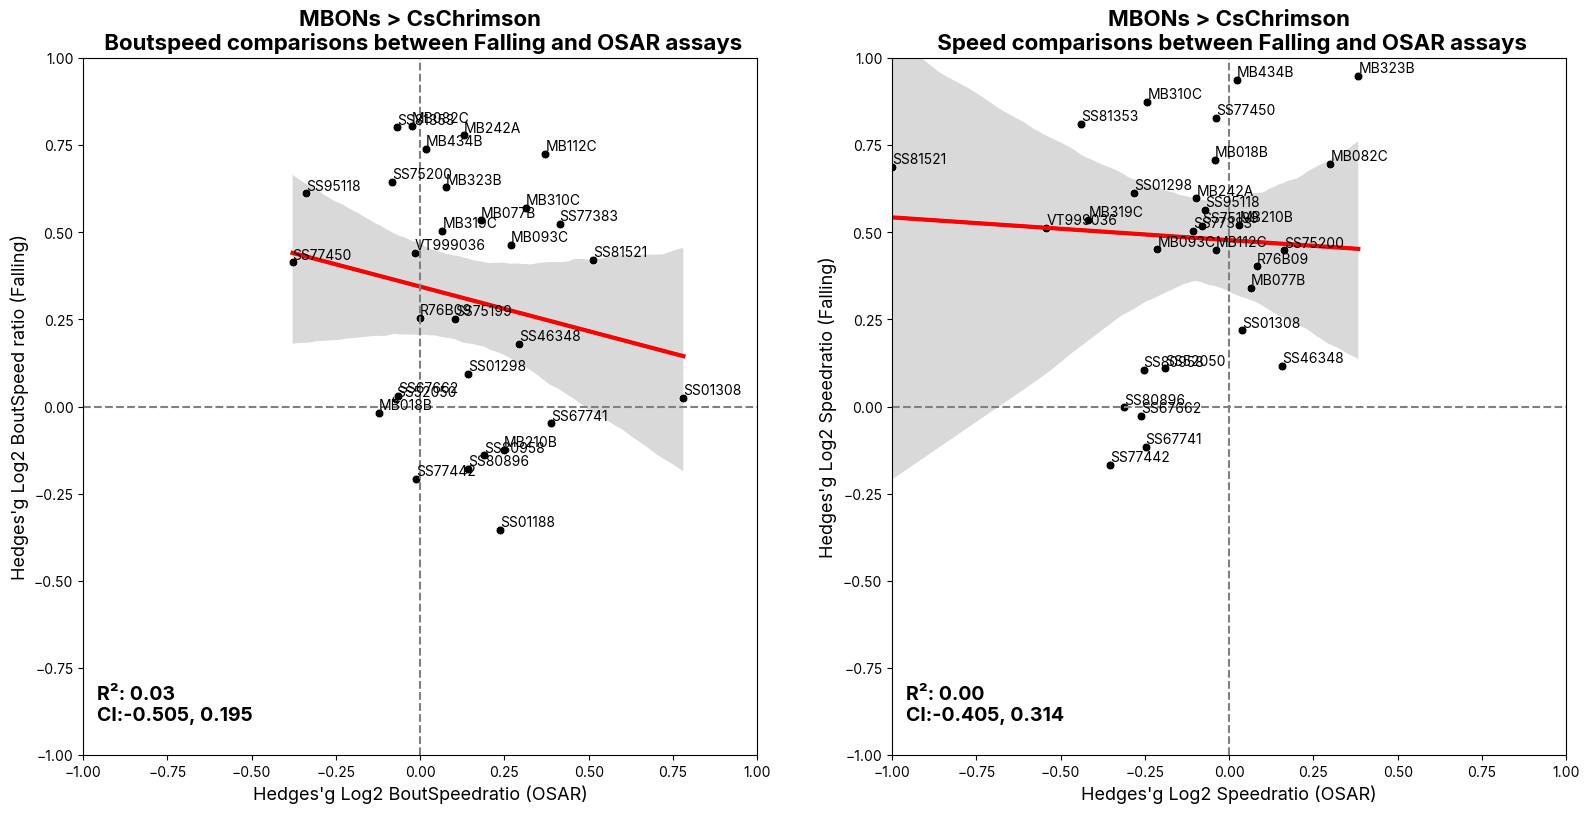

In [73]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios":[1,1]})



# First subplot
x_label_1 = "Log2 Bout Speed ratio_Δg_OSAR"
y_label_1 = 'Log2 Bout Speed ratio_Δg_Falling'

#df02omitteddf = omission(df_specificmbon)
df02omitteddf = df_specificmbon.copy()

sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

axscatter_o[0].set_xlabel("Hedges'g Log2 BoutSpeedratio (OSAR)", fontsize = 13)
axscatter_o[0].set_ylabel("Hedges'g Log2 BoutSpeed ratio (Falling)", fontsize = 13)
axscatter_o[0].grid(False)
axscatter_o[0].set_ylim([-1, 1])
axscatter_o[0].set_xlim([-1, 1])
axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].set_title("MBONs > " + responderrename + "\n Boutspeed comparisons between Falling and OSAR assays", weight = "bold", fontfamily = "Inter", fontsize = 16)
axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omitteddf['MBON']):
    axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

#correlation for first subplot
pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


# Second subplot
x_label_2 = "Log2 Speed ratio_Δg_OSAR"
y_label_2 = 'Log2 Speed ratio_Δg_Falling'

sns.regplot(x=x_label_2, y=y_label_2, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
sns.regplot(x=x_label_2, y=y_label_2, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
sns.scatterplot(x=x_label_2, y=y_label_2, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[1])

axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
axscatter_o[1].set_ylabel("Hedges'g Log2 Speedratio (Falling)", fontsize = 13)
axscatter_o[1].grid(False)
axscatter_o[1].set_ylim([-1, 1])
axscatter_o[1].set_xlim([-1, 1])
axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[1].set_title("MBONs > " + responderrename + "\n Speed comparisons between Falling and OSAR assays", weight = "bold", fontsize = 16)
axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omitteddf['MBON']):
    axscatter_o[1].annotate(k, (df02omitteddf.loc[n,x_label_2], df02omitteddf.loc[n,y_label_2]+0.01), fontsize = 10)

#correlation for second subplot
pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df02omitteddf[x_label_2], df02omitteddf[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2)

# plt.savefig(filesavedir + date + "_" + responder + "_linreg.png", dpi = 1200, bbox_inches='tight')
# plt.savefig(filesavedir + date + "_" + responder + "_linreg.svg")

## Clustering

weighted euclidean


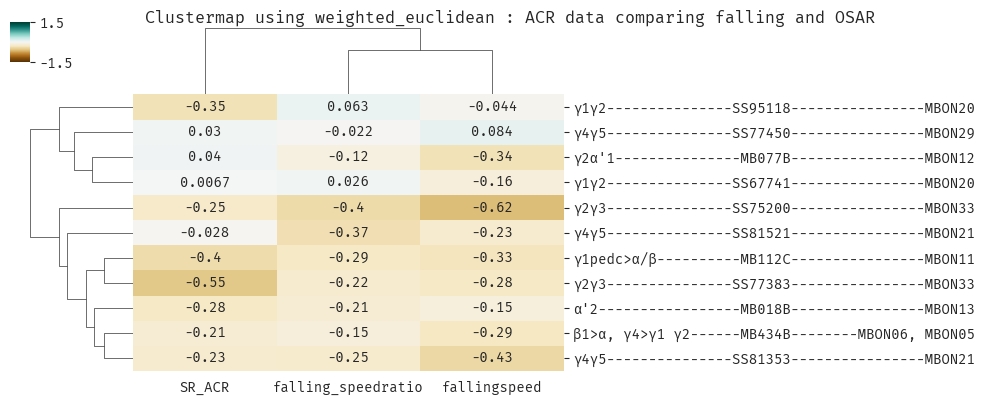

In [ ]:
methodlist = ['weighted']
metriclist = ['euclidean']
       
df601 = df600.copy()
df601['totalnaming'] = df601['MBON'] + "; " + df601['Name'] + "; " + df601['Lobe']
df601newset = df601.set_index('totalnaming').filter(items = ["falling_speedratio", "fallingspeed", "SR_ACR"])
plt.rcParams["font.family"] = "Inter"

ylabellist = []
for n, k, z in zip(df601['MBON'],df601['Lobe'], df601['Name']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df601newset, cmap='BrBG', metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5, annot=True,
                            cbar_kws = dict(shrink = 0.15, ticks = [-1.5,1.5]), figsize=(10, 4), cbar_pos=(0, 0.87, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : ACR data comparing falling and OSAR' , weight='bold', fontsize =12, y =1.0)

        #plt.rcParams["font.family"] = "Inter"
        #plt.savefig(openPath + "images\\" + date + "_" + responder + "_clustermap_" + methodd + "_" + metricc + "_betweenChrimsonandACR.png", dpi = 1200)

## Neurotransmitter types

In [76]:
totalmetriccomparison.columns

Index(['Fall number_ΔΔ_Falling', 'Speed_Δg_Falling',
       'Max height climbed_Δg_Falling', 'Bout speed_Δg_Falling',
       'Pause position_Δg_Falling', 'Max velocity_Δg_Falling',
       'Straightness Index_Δg_Falling', 'Duration of bouts_Δg_Falling',
       'Number of Bouts_Δg_Falling', 'responder', 'genotypeandresponder',
       'MBON', 'PI_Δg_OSAR', 'Log2 Speed ratio_Δg_OSAR',
       'Log2 Bout Speed ratio_Δg_OSAR', 'Light Attraction Index_Δg_OSAR',
       'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_Falling'],
      dtype='object')

In [75]:
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics.xlsx")

df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
df_nt2 =  df_nt2[~df_nt2['MBON'].isin(['VT999036'])]

ntloblist = []
mbonloclst = []
df_nttotal = df_nt2.copy()
for n in df_nt2['MBON']:    
    ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df_nttotal['NT'] = ntloblist
df_nttotal['Name'] = mbonloclst

#single responder
labellingdf = pd.DataFrame()
naming = df_nttotal['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df_nttotal['NT'].to_frame().rename(columns = {"NT": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
labellingdf['Merge'] = newlabel

In [80]:
df_neurotrans

,Fall number_ΔΔ_Falling,Speed_Δg_Falling,Max height climbed_Δg_Falling,Bout speed_Δg_Falling,Pause position_Δg_Falling,Max velocity_Δg_Falling,Straightness Index_Δg_Falling,Duration of bouts_Δg_Falling,Number of Bouts_Δg_Falling,responder,MBON,PI_Δg_OSAR,Log2 Speed ratio_Δg_OSAR,Log2 Bout Speed ratio_Δg_OSAR,Light Attraction Index_Δg_OSAR,Log2 Bout Speed ratio_Δg_Falling,Log2 Speed ratio_Δg_Falling,NT,Name
0,0.209,0.307,0.382,-0.680,0.404,0.636,-0.490,-0.706,1.030,ACR,SS77442,-0.162897,-0.054518,-0.214898,0.140150,0.038,0.603,Acetylcholine,MBON19
1,0.015,-0.328,-0.005,-0.290,-0.182,-0.743,-0.554,-0.110,0.173,ACR,MB112C,-0.143145,-0.527717,-0.550738,-0.975927,0.455,0.135,GABA,MBON11
2,0.212,0.084,0.343,0.091,0.239,-0.394,-0.122,0.203,0.348,ACR,SS77450,-0.029700,-0.029858,-0.178681,-0.239279,0.060,0.091,Acetylcholine,MBON29
3,-0.184,0.058,0.147,-0.190,0.153,-0.966,0.459,0.520,-0.398,ACR,R76B09,-0.013538,0.383957,0.026621,0.191586,0.270,-0.108,Glutamate,MBON05
4,0.437,-0.213,-0.002,-0.546,-0.033,-0.247,0.529,-0.107,0.160,ACR,MB323B,-0.011453,0.073496,-0.442046,-0.116454,-0.151,0.020,Glutamate,MBON07
5,-0.013,-0.230,0.402,-0.224,0.220,-0.776,0.245,-0.041,0.354,ACR,SS81521,0.031084,-0.066401,-0.019163,-0.017037,0.405,0.262,Acetylcholine,MBON21
6,-0.450,-0.077,0.208,-0.285,0.266,-0.251,0.208,-0.007,0.005,ACR,SS01298,0.041679,-0.125925,-0.192269,-0.208233,0.490,0.974,Acetylcholine,"MBON16 , MBON17"
7,0.532,-0.112,0.097,0.192,0.006,-0.350,-0.474,0.017,0.035,ACR,SS67662,0.043488,-0.023303,-0.096580,0.119664,0.160,0.030,Acetylcholine,MBON29
8,-0.138,-0.345,0.428,-0.236,0.330,-0.723,-0.699,0.002,0.378,ACR,MB077B,0.048026,-0.143410,-0.702063,-0.059052,0.680,0.257,Acetylcholine,MBON12
9,0.019,-0.294,0.486,0.174,0.479,-0.873,0.111,0.346,-0.673,ACR,MB434B,0.093572,-0.132527,-0.286662,0.017865,0.109,-0.150,Glutamate,"MBON06, MBON05"


Text(0.5, 0.98, 'MBONs > GtACR1_Linear regressions across NT types ')

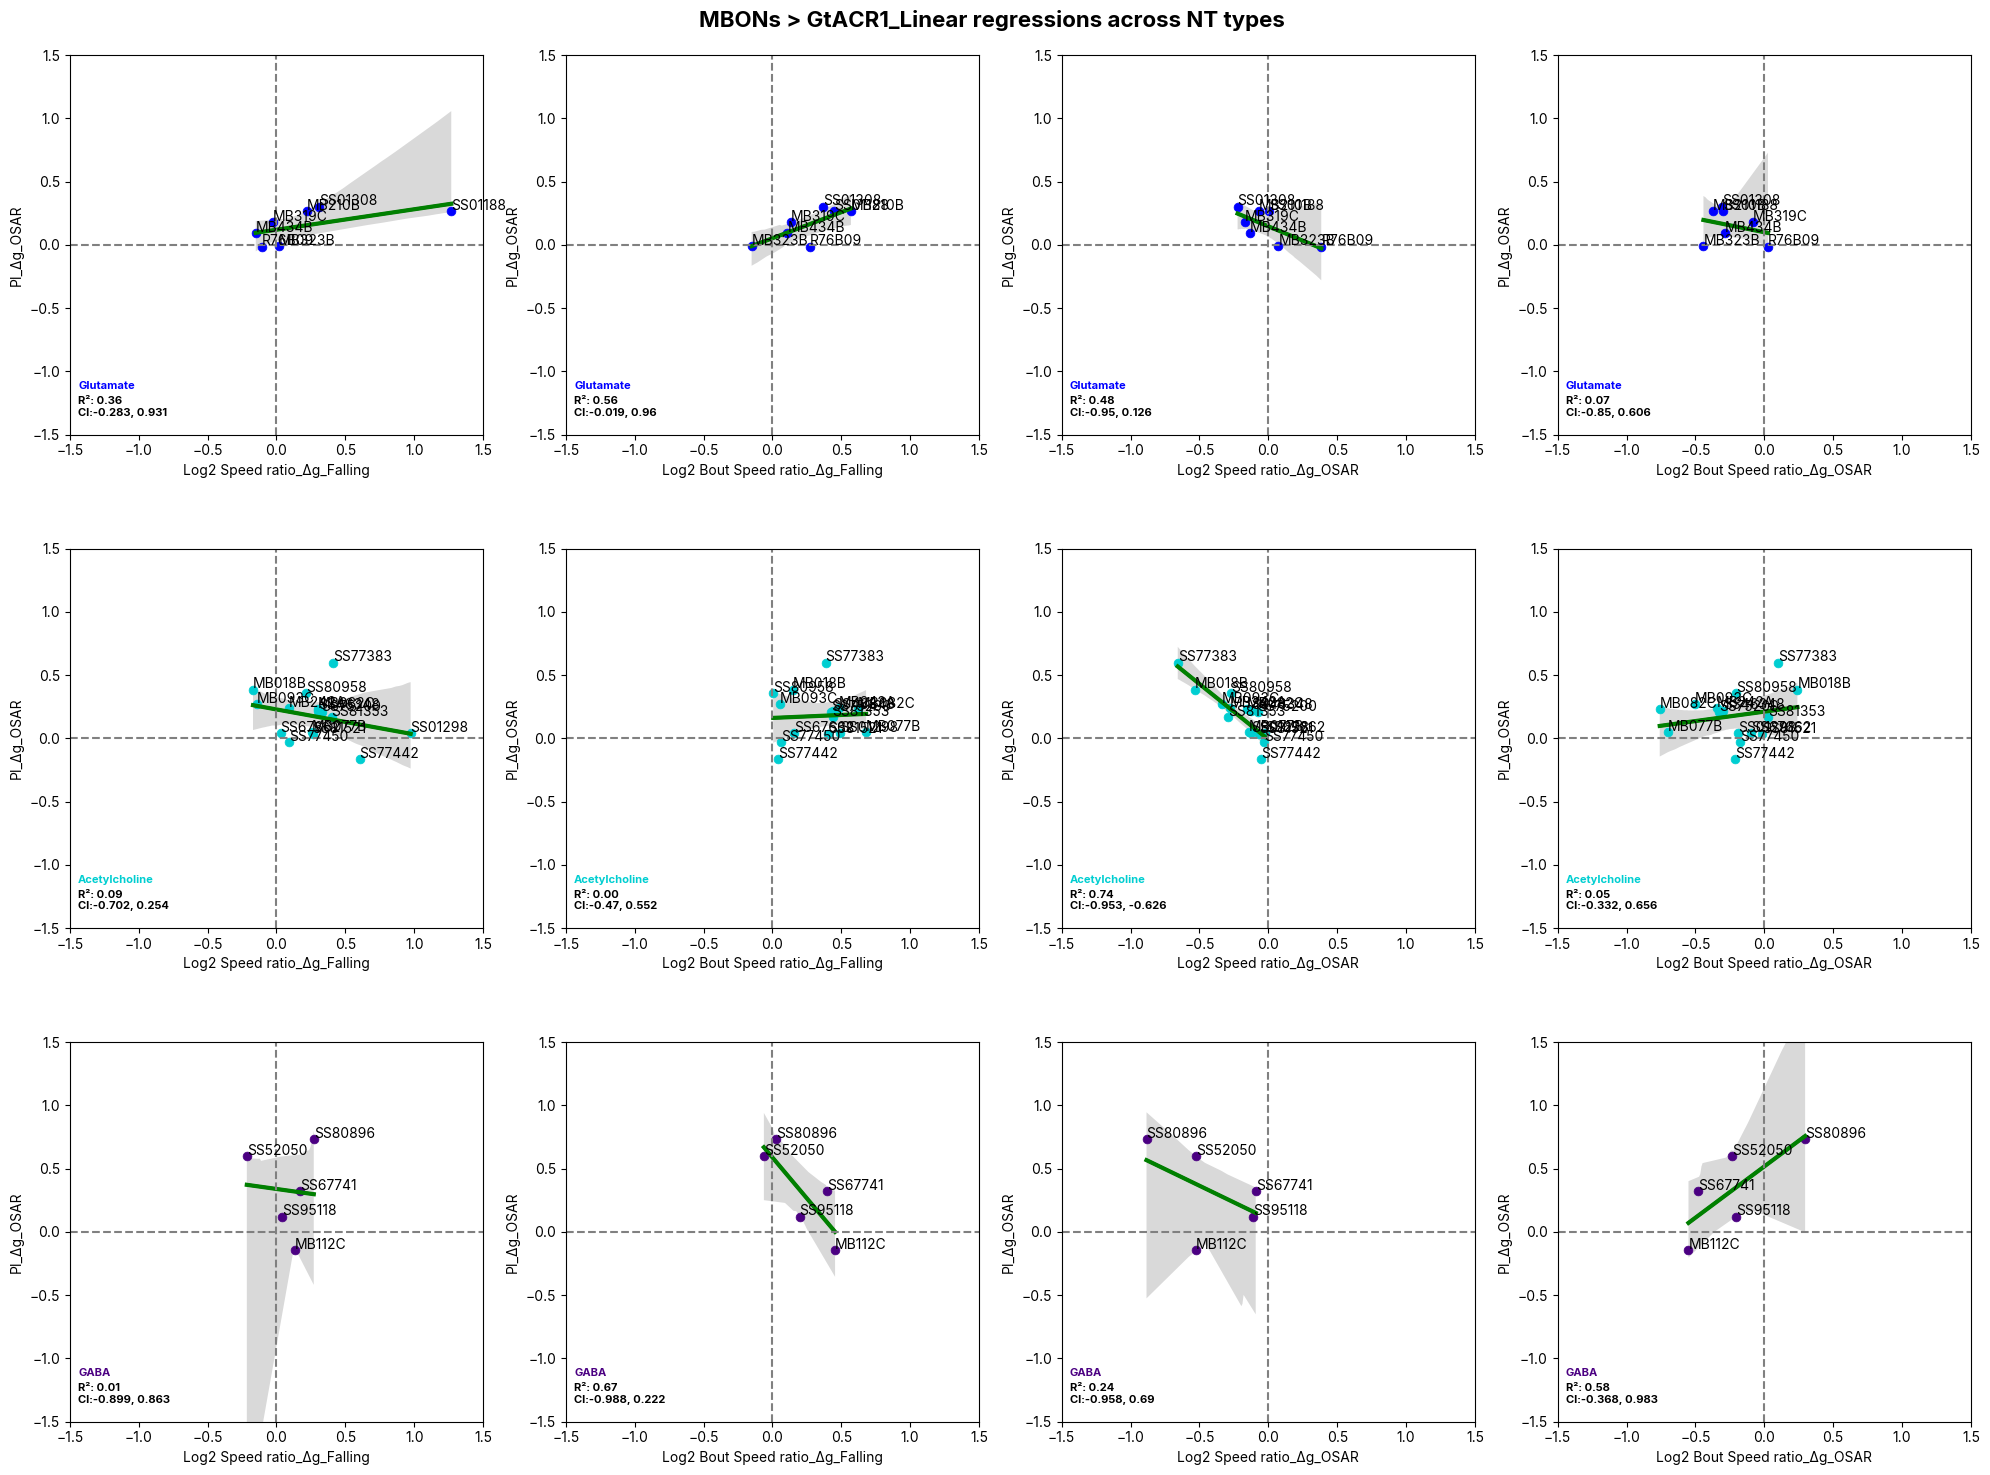

In [79]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "ACR"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]


figntplot, axes = plt.subplots(3,4, figsize=(20,15))
axscatter_nt = axes.flatten()
nttypes = ['Glutamate', "Acetylcholine", "GABA"]

metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
plotcounter = 0

for n,j in zip(nttypes, nttypes_color):
    unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
    
    for k in metrictype:
        x_label_1 = k
        y_label_1 = 'PI_Δg_OSAR'      

        #data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1] < 0.2) & (unfiltered_dfnt[y_label_1] < 0.2))].reset_index(drop=True)
        data_nt = unfiltered_dfnt.copy()
      
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter]) #ci color
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])  #line color
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s = 40, color = j, edgecolors = "face", ax=axscatter_nt[plotcounter])

        axscatter_nt[plotcounter].grid(False)
        axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
        axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
        axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls= '--')
        axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls= '--')
       
        axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)

        for m, p in enumerate(data_nt['MBON']):
            axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize = 10)

        #correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
        civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                                ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 8)
        
        #naming of nt type
        axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color= j, weight="bold", fontsize=8)
        plotcounter +=1
        
plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2, hspace = 0.3)

figntplot.suptitle("MBONs > " + responderrename + "_Linear regressions across NT types ", weight = "bold", fontfamily = "Inter", fontsize = 16)

# plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes.png", dpi = 1200, bbox_inches='tight')
# plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes.svg")

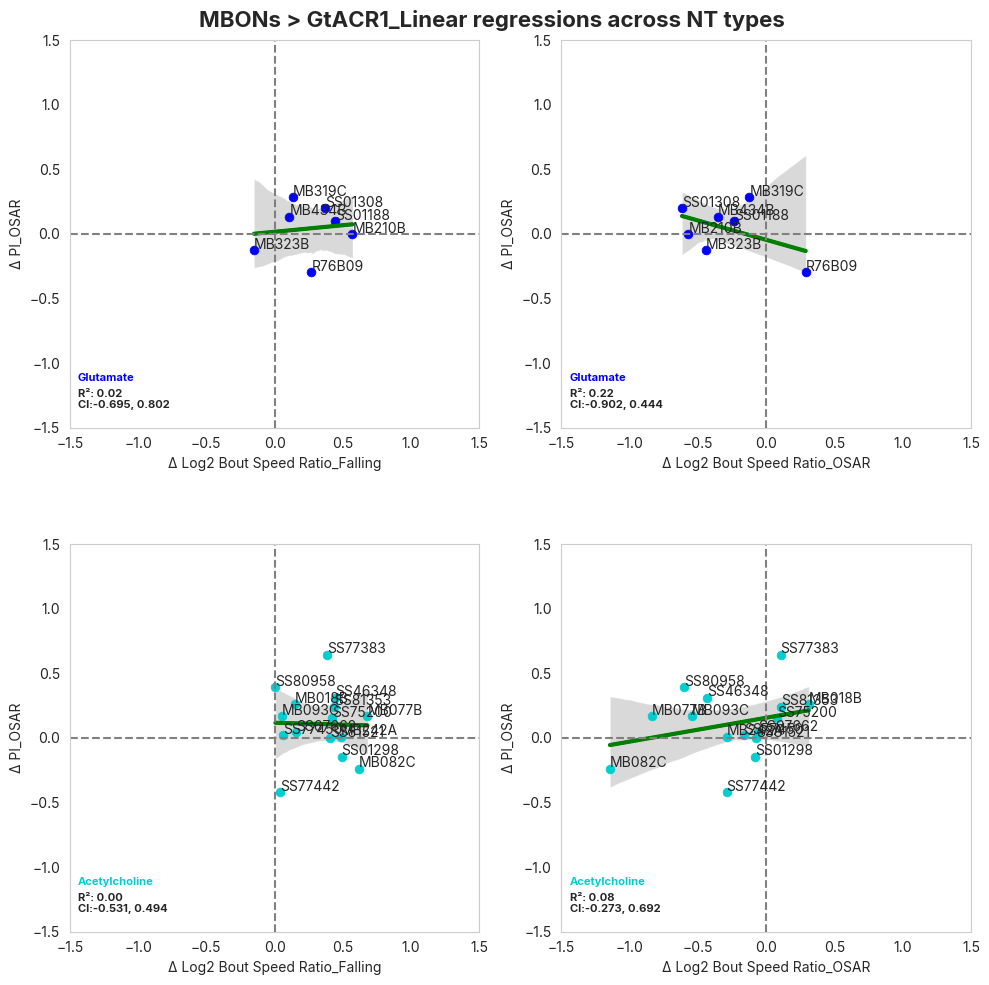

In [73]:
##for poster only

import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "ACR"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by = "Δ PI_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by = "Δ PI_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]


figntplot, axes = plt.subplots(2,2, figsize=(10,10))
axscatter_nt = axes.flatten()
nttypes = ['Glutamate', "Acetylcholine"]

metrictype = ['Δ Log2 Bout Speed Ratio_Falling','Δ Log2 Bout Speed Ratio_OSAR']
plotcounter = 0

for n,j in zip(nttypes, nttypes_color):
    unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
    
    for k in metrictype:
        x_label_1 = k
        y_label_1 = 'Δ PI_OSAR'      

        #data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1] < 0.2) & (unfiltered_dfnt[y_label_1] < 0.2))].reset_index(drop=True)
        data_nt = unfiltered_dfnt.copy()
      
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter]) #ci color
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])  #line color
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s = 40, color = j, edgecolors = "face", ax=axscatter_nt[plotcounter])

        axscatter_nt[plotcounter].grid(False)
        axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
        axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
        axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls= '--')
        axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls= '--')
       
        axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)

        for m, p in enumerate(data_nt['MBON']):
            axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize = 10)

        #correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
        civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                                ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 8)
        
        #naming of nt type
        axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color= j, weight="bold", fontsize=8)
        plotcounter +=1
        
plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2, hspace = 0.3)

figntplot.suptitle("MBONs > " + responderrename + "_Linear regressions across NT types ", weight = "bold", fontfamily = "Inter", fontsize = 16)

plt.savefig(filesavedir + "temp.png", dpi = 1200, bbox_inches='tight')
